Our quantifications match the visualization -- subsetting to the test conditions of interest in a given fold

In [1]:
import warnings

warnings.resetwarnings()

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*__version__ is deprecated.*"
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Observation names are not unique.*"
)

warnings.filterwarnings(
    "ignore",
    module=r"scanpy(\..*)?$"
)

warnings.filterwarnings(
    "ignore",
    module=r"anndata(\..*)?$"
)

warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings(
    "ignore",
    category=ImplicitModificationWarning
)


In [2]:
import os
import sys
import warnings
import copy
from collections import defaultdict
import itertools

from tqdm import trange

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cosine as cosine_distance
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, pb_y_pred

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

merged_adatas_rand = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_rand_predictions.pickle'.format(author))
)


cspm_ = io.read_pickled_object(os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle'.format(author)))
mod_types = {
    'actual': merged_adatas, 
    'random': merged_adatas_rand
}


In [5]:
n_folds = 5

In [6]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


# Cosine Distance

We will use Systema[https://www.nature.com/articles/s41587-025-02777-8] cosine distance metric to quantify this condition space relative to the random baseline

The above visualizations can be quantified relative to the random baseline, showing that we are capturing the relative global geometry of the perturbation space accurately. 

This metric most accurately reflects the visualization comparison we conducted in Notebook 01Ai

In [9]:
def pert_centroids(adata, pls_model = None):
    if pls_model is None:
        X = adata.to_df()
    else:
        X = pd.DataFrame(pls_model.transform(adata.X), 
                         index = adata.obs_names, 
                         columns = ['LV{}'.format(i+1) for i in range(pls_model.n_components)]
                        )
    X[pert_col] = adata.obs[pert_col].astype(str).tolist()
    X = X.groupby(pert_col).mean()
    
    return X

def get_cos_dist(fold, tf_adata_merged, pls_model = None):
    distances = defaultdict(list)
    
    split = get_split(fold, author)
    test_conds = split['test_conds']
    ctrl_conds = list({'^'.join([tc.split('^')[0], ctrl_pert]) for tc in test_conds})

    cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[cond_mask, :].copy()
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy() #predicted test conditions only
    tf_adata_actual_pert = tf_adata[tf_adata.obs.condition.isin(test_conds), :] # actual data
    tf_adata_actual_ctrl = tf_adata[tf_adata.obs.condition.isin(ctrl_conds), :] # corresponding controls

    X_pred = pert_centroids(tf_adata_predicted, pls_model = pls_model)
    X_actual_pert = pert_centroids(tf_adata_actual_pert, pls_model = pls_model)
    assert sorted(X_pred.index) == sorted(X_actual_pert.index), 'Test conditions are not consistent'

    if pls_model is None:
        all_pert_centroid = tf_adata_actual_pert.to_df().mean(axis = 0).values 
    else:
        all_pert_centroid = pd.DataFrame(
            pls_model.transform(tf_adata_actual_pert.X), 
            index = tf_adata_actual_pert.obs_names, 
            columns = ['LV{}'.format(i+1) for i in range(pls_model.n_components)]
                        )
        all_pert_centroid = all_pert_centroid.mean(axis = 0).values
        
    ctrl_centroid = pert_centroids(tf_adata_actual_ctrl, pls_model = pls_model).values[0]

    X_pred = X_pred.loc[X_actual_pert.index, :].copy()

    for pert in X_pred.index:
        actual_pert_centroid = X_actual_pert.loc[pert, :].values
        pred_pert_centroid = X_pred.loc[pert, :].values

        v_actual_pert = actual_pert_centroid - ctrl_centroid
        v_ctrl = all_pert_centroid - ctrl_centroid
        cos_dist_actual = cosine_distance(v_actual_pert, v_ctrl)

        v_pred_pert = pred_pert_centroid - ctrl_centroid
        cos_dist_pred = cosine_distance(v_pred_pert, v_ctrl)
        
        distances['fold'].append(fold)
        distances['perturbation'].append(pert)
        distances['actual'].append(cos_dist_actual)
        distances['predicted'].append(cos_dist_pred)
    
    return pd.DataFrame(distances)

## Full Feature Space

Because the Systema metric requires controls, we either need to use the full feature space, or a PLS fit on test conditions AND the corresponding controls, which is different from what was used in the visualization of 01Ai (pls models of just test conditions).

In [10]:
cos_distances = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()
    
    
    cos_distances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = None)
    cos_distances.append(cos_distances_fold)
    
cos_distances = pd.concat(cos_distances, ignore_index = True)
cos_distances['mod_type'] = 'actual'

cos_distances_rand = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas_rand[key].copy()
    
    
    distnances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = None)
    cos_distances_rand.append(distnances_fold)
    
cos_distances_rand = pd.concat(cos_distances_rand, ignore_index = True)
cos_distances_rand['mod_type'] = 'random'

cos_distances = pd.concat([cos_distances, cos_distances_rand], ignore_index = True)
cos_distances['error'] = np.abs(cos_distances["predicted"] - cos_distances["actual"]) #/ np.sqrt(2)
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type, 
    categories = ['actual', 'random'], 
    ordered = True
)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 15.02it/s]


In [12]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

''

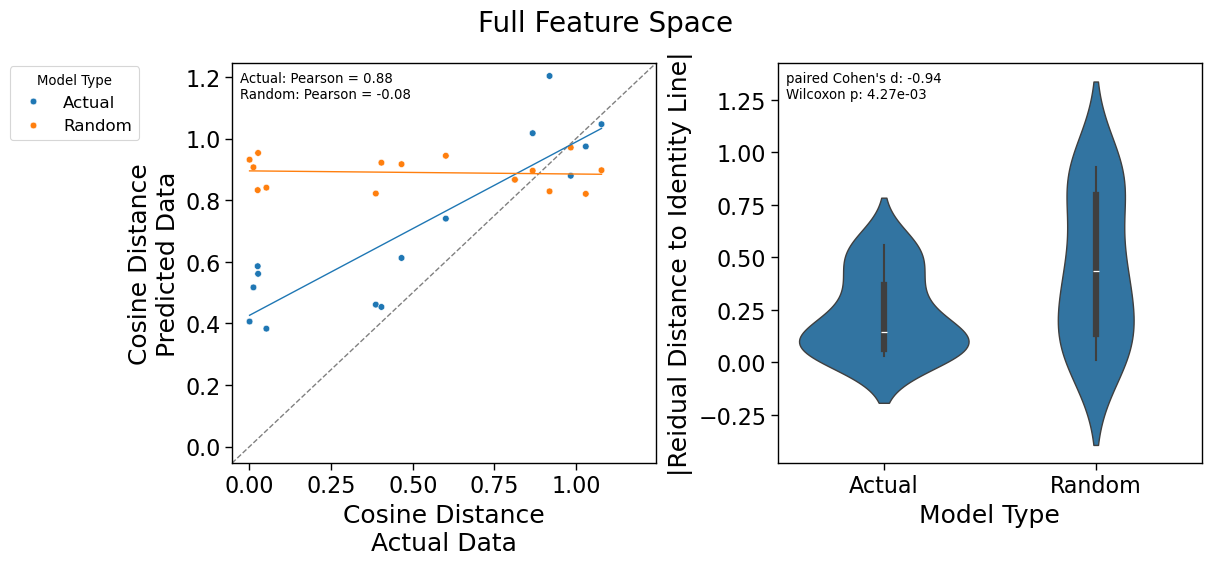

In [20]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0
sns.scatterplot(data = cos_distances, x = 'actual', y = 'predicted', hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = cos_distances[cos_distances.mod_type == mod_type].copy()

    sns.regplot(
        data=viz_df,
        x="actual",
        y="predicted",
        ax=ax[j],
        scatter=False,      
        ci = None,
        line_kws={"linewidth": 1}, 
    )

    
# pearson
pr_actual = stats.pearsonr(cos_distances[cos_distances.mod_type == 'actual'].actual,
                           cos_distances[cos_distances.mod_type == 'actual'].predicted).statistic
pr_noadv = stats.pearsonr(cos_distances[cos_distances.mod_type == 'random'].actual,
                          cos_distances[cos_distances.mod_type == 'random'].predicted).statistic

ax[j].text(
    0.02, 0.98,
    "{}: Pearson = {:.2f}\n{}: Pearson = {:.2f}".format('Actual', pr_actual, 'Random', pr_noadv),
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ax[j].set_xlabel('Cosine Distance\nActual Data')
ax[j].set_ylabel('Cosine Distance\nPredicted Data')

xmin, xmax = ax[j].get_xlim()
ymin, ymax = ax[j].get_ylim()

ax_min = min(xmin, ymin)
ax_max = max(xmax, ymax)

ax[j].set_xlim(ax_min, ax_max)
ax[j].set_ylim(ax_min, ax_max)

ax[j].plot(
    [ax_min, ax_max],
    [ax_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)


handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = cos_distances[cos_distances.mod_type == 'actual']['error'].values
b = cos_distances[cos_distances.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = cos_distances, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Residual Distance')
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Reidual Distance to Identity Line|')

fig.suptitle('Full Feature Space', y = 1.1, fontsize = 20)
for ext in ['png', 'svg']:
    fig.savefig(
        os.path.join(data_path, 'figures', '{}_cosine_distance.{}'.format(author, ext)),
        dpi=1200 if ext == '.png' else None,  # DPI only matters for raster
        bbox_inches='tight',
        facecolor='none',  # transparent background (nice for slides)
    )
;

## PLS Space

We repeat the analysis in PLS space. Note, these PLS models were fit on the test conditions AND their corresponding controls (because the Systema metric requires controls). This is different from what was used in teh visualization of 01Ai (pls models of just test conditions).

In [26]:
cspcm = io.read_pickled_object(
    os.path.join(data_path, 'interim', '{}_test_condition_PLS_models_with_control.pickle'.format(author))
)

In [29]:
distances = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()
    
    
    distances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = cspcm[fold])
    distances.append(distances_fold)
    
distances = pd.concat(distances, ignore_index = True)
distances['mod_type'] = 'actual'

distances_rand = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas_rand[key].copy()
    
    
    distnances_fold = get_cos_dist(fold, tf_adata_merged, pls_model = cspcm[fold])
    distances_rand.append(distnances_fold)
    
distances_rand = pd.concat(distances_rand, ignore_index = True)
distances_rand['mod_type'] = 'random'

distances = pd.concat([distances, distances_rand], ignore_index = True)
cos_distances = distances
cos_distances['error'] = np.abs(cos_distances["predicted"] - cos_distances["actual"]) #/ np.sqrt(2)
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type, 
    categories = ['actual', 'random'], 
    ordered = True
)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 10.09it/s]


''

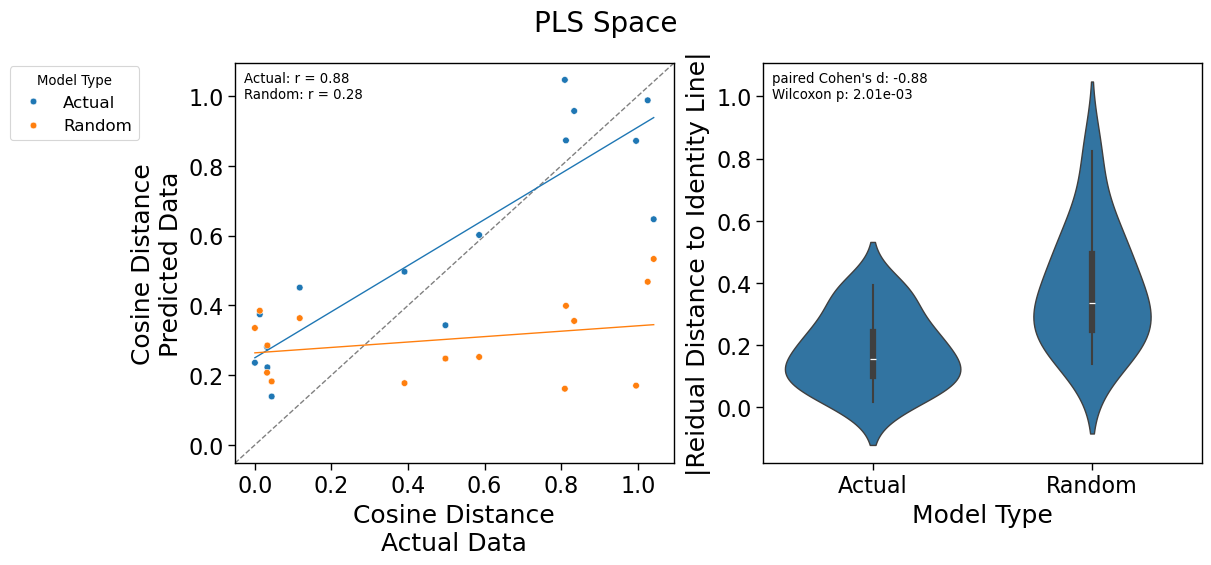

In [30]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0
sns.scatterplot(data = cos_distances, x = 'actual', y = 'predicted', hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = cos_distances[cos_distances.mod_type == mod_type].copy()

    sns.regplot(
        data=viz_df,
        x="actual",
        y="predicted",
        ax=ax[j],
        scatter=False,      
        ci = None,
        line_kws={"linewidth": 1}, 
    )

    
# pearson
pr_actual = stats.pearsonr(cos_distances[cos_distances.mod_type == 'actual'].actual,
                           cos_distances[cos_distances.mod_type == 'actual'].predicted).statistic
pr_noadv = stats.pearsonr(cos_distances[cos_distances.mod_type == 'random'].actual,
                          cos_distances[cos_distances.mod_type == 'random'].predicted).statistic

ax[j].text(
    0.02, 0.98,
    "{}: r = {:.2f}\n{}: r = {:.2f}".format('Actual', pr_actual, 'Random', pr_noadv),
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ax[j].set_xlabel('Cosine Distance\nActual Data')
ax[j].set_ylabel('Cosine Distance\nPredicted Data')

xmin, xmax = ax[j].get_xlim()
ymin, ymax = ax[j].get_ylim()

ax_min = min(xmin, ymin)
ax_max = max(xmax, ymax)

ax[j].set_xlim(ax_min, ax_max)
ax[j].set_ylim(ax_min, ax_max)

ax[j].plot(
    [ax_min, ax_max],
    [ax_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)


handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = cos_distances[cos_distances.mod_type == 'actual']['error'].values
b = cos_distances[cos_distances.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = cos_distances, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Residual Distance')
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Reidual Distance to Identity Line|')

fig.suptitle('PLS Space', y = 1.1, fontsize = 20)
;

# EMD Loss

This is the simple single-cell loss of the model prediction

Latent space this time is just fit on conditions, does not include controls.

In [21]:
# merged_adatas_noadv = io.read_pickled_object(
#     os.path.join(data_path, 'processed', '{}_scLEMBAS_noadv_predictions.pickle'.format(author))
# )


In [22]:

# format for input to emd loss function
cspm = {}
for fold in range(5):
    split = get_split(fold, author)
    test_conds = split['test_conds']
    for test_cond in test_conds:
        cspm[test_cond] = copy.deepcopy(cspm_[fold])



In [9]:
def load_test_tfadata(fold, merged_adatas):
    key = 'none'
    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()
        
    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'
    
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')
    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()    
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted

In [24]:
loss_res = defaultdict(list)

for (fold, (mod_type, merged_adatas_), latent_models) in itertools.product(range(n_folds), mod_types.items(), [None, cspm]):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, merged_adatas_)
    emd_loss = distances.get_EMD_loss(
        tf_adata_actual, tf_adata_predicted, 
        groupby_col = 'condition', # per test condition
        latent_models = latent_models, 
    )['Mean EMD Loss']


    loss_res['Mean EMD Loss'].append(emd_loss)
    loss_res['Space'].append('Full Feature Space' if latent_models is None else 'Test Condition Specific PLS Space')
    loss_res['Fold'].append(fold + 1)
    loss_res['mod_type'].append(mod_type)
        
loss_res = pd.DataFrame(loss_res) 
loss_res.mod_type = pd.Categorical(loss_res.mod_type, 
                                   categories = ['actual', 'random'], 
                                   ordered = True
                                  ).map({
    'actual': 'Actual', 'random': 'Random'
    
})

In [25]:
def emd_viz(
    space, 
    loss_res,
    loss_col: str = 'Mean EMD Loss', 
    fig_name = None, 
    show_fig = True
):

    viz_df = loss_res[loss_res.Space == space].copy()
    
    fig, ax = plt.subplots(figsize = (4.5, 4), constrained_layout = True)


    sns.violinplot(data = viz_df, x = 'mod_type', y = loss_col)
    ax.set_title(space)
    ax.set_xlabel('Model Type')

    
    # stats
    a = viz_df[viz_df.mod_type == 'Actual'][loss_col].values
    b = viz_df[viz_df.mod_type == 'Random'][loss_col].values

    pval = stats.wilcoxon(a, b, alternative = 'less').pvalue
    cd = cohens_d_paired(a,b)
    ax.text(
        0.02, 0.98,
        f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
        transform=ax.transAxes,
        ha="left", va="top", 
        fontsize=12
    )
    
    if fig_name is not None:
        dirpath  = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _  = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        
        plt.savefig(
            "{}.png".format(out_base),
            dpi=1200,
            bbox_inches="tight",
            transparent=True,
        )

        plt.savefig(
            "{}.svg".format(out_base),
            format="svg",
            bbox_inches="tight",
        )
        
    if show_fig:
        plt.show()
    ;

In [26]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

,Mean Per-Condition EMD Loss,Space,Fold,mod_type
0,62.889950,Full Feature Space,1,Actual
1,16.840365,Test Condition Specific PLS Space,1,Actual
2,188.932739,Full Feature Space,1,Random
3,41.497365,Test Condition Specific PLS Space,1,Random
4,61.012924,Full Feature Space,2,Actual
5,26.271233,Test Condition Specific PLS Space,2,Actual
6,208.712891,Full Feature Space,2,Random
7,44.013665,Test Condition Specific PLS Space,2,Random
8,53.898449,Full Feature Space,3,Actual
9,36.595794,Test Condition Specific PLS Space,3,Actual


In [29]:
y_label = 'Mean Per-Condition EMD Loss'

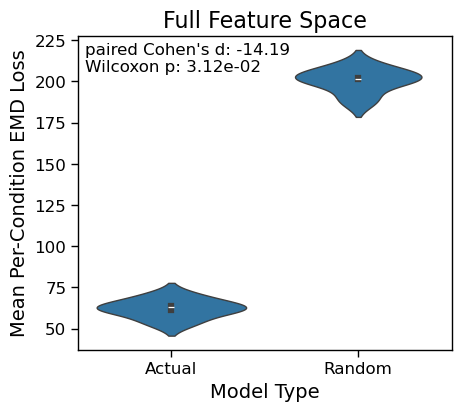

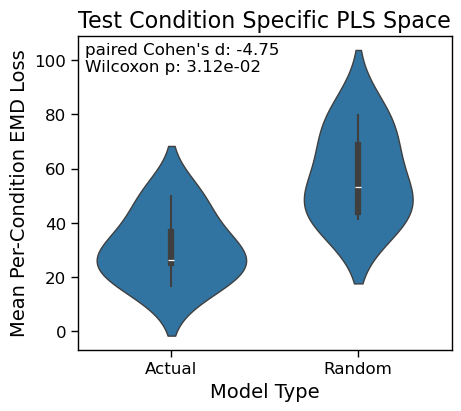

In [32]:
for space in ['Full Feature Space', 'Test Condition Specific PLS Space']:
    emd_viz(
        space, 
        loss_res.rename(columns = {'Mean EMD Loss': y_label}),
        loss_col = y_label,
        fig_name = os.path.join(data_path, 'figures', '{}_{}_EMD_test_loss'.format(author, space)), 
        show_fig = True
    )

# Rank loss

Perturbench (https://arxiv.org/html/2408.10609v3)


Because the random baseline yields a degenerate distribution at 0.5, significance was assessed using a one-sample binomial (sign) test against chance, evaluating whether performance exceeded 0.5 across folds.

In [7]:
cspm = cspm_.copy() 

In [10]:
loss_res = defaultdict(list)

for (fold, (mod_type, merged_adatas_), latent_models) in itertools.product(range(n_folds), mod_types.items(), [None, cspm]):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, merged_adatas_)
    if latent_models is not None:
        latent_model = copy.deepcopy(cspm[fold])
    else:
        latent_model = None
    
    rsa, rs = distances.rank_score(
        tf_adata_actual, 
        tf_adata_predicted, 
        pert_col = pert_col,
        distance_metric = 'manhattan', 
        latent_model = latent_model,
    )


    loss_res['Mean Rank Score'].append(rsa)
    loss_res['All Rank Scores'].append(rs)
    loss_res['Space'].append('Full Feature Space' if latent_model is None else 'Test Condition Specific PLS Space')
    loss_res['Fold'].append(fold + 1)
    loss_res['mod_type'].append(mod_type)
        
loss_res = pd.DataFrame(loss_res) 
loss_res.mod_type = pd.Categorical(loss_res.mod_type, 
                                   categories = ['actual', 'random'], 
                                   ordered = True
                                  ).map({
    'actual': 'Actual', 'random': 'Random'
    
    
})

# you are here:

correct the pvalue test

In [23]:
def rank_viz(
    space, 
    loss_res,
    loss_col: str = 'Mean EMD Loss', 
    fig_name = None, 
    show_fig = True
):

    viz_df = loss_res[loss_res.Space == space].copy()
    
    fig, ax = plt.subplots(figsize = (4, 3), constrained_layout = True)


    sns.violinplot(data = viz_df, x = 'mod_type', y = loss_col)
    ax.set_title(space)
    ax.set_xlabel('Model Type')

    
    # stats
    actual = viz_df[viz_df.mod_type == 'Actual'][loss_col].values
    rand = viz_df[viz_df.mod_type == 'Random'][loss_col].values

#     n_pos = np.sum(actual > 0.5)
#     n_tot = len(actual)

#     pval = stats.binomtest(
#         n_pos,
#         n_tot,
#         p=0.5,
#         alternative="greater"
#     ).pvalue

    _, pval = stats.wilcoxon(actual, rand, alternative='greater')


    cd = cohens_d_paired(actual, rand)
    
    ax.text(
        0.525, 0.96, 
        "Wilcoxon p: {:.2E} \n paired Cohen's d: {:.1f}".format(pval, cd),
        transform=ax.transAxes,
        ha="left", va="top", 
        fontsize=10
    )
    
    
#     ax.text(
#         0.55, 0.98,
#         f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
#         transform=ax.transAxes,
#         ha="left", va="top", 
#         fontsize=12
#     )
    
    if fig_name is not None:
        dirpath  = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _  = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        
        plt.savefig(
            "{}.png".format(out_base),
            dpi=1200,
            bbox_inches="tight",
            transparent=True,
        )

        plt.savefig(
            "{}.svg".format(out_base),
            format="svg",
            bbox_inches="tight",
        )
        
    if show_fig:
        plt.show()
    ;

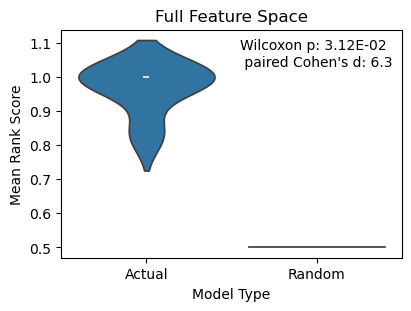

/home/hmbaghda/orcd/pool/scLEMBAS/analysis/figures/McCauley_feature_space_rank_test_loss.png


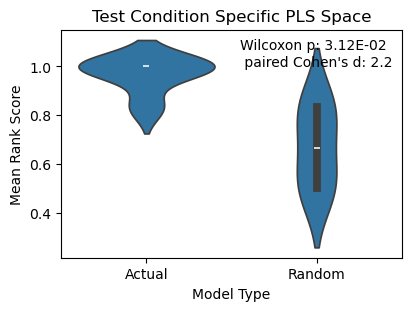

/home/hmbaghda/orcd/pool/scLEMBAS/analysis/figures/McCauley_pls_space_rank_test_loss.png


In [25]:
fs_map = {'Full Feature Space': 'feature_space', 
          'Test Condition Specific PLS Space': 'pls_space'
         }
for space in ['Full Feature Space', 'Test Condition Specific PLS Space']:
    rank_viz(
        space, 
        loss_res,
        loss_col = 'Mean Rank Score',
        fig_name = os.path.join(data_path, 'figures', '{}_{}_rank_test_loss.png'.format(author, fs_map[space])), 
        show_fig = True
    )
    print(os.path.join(data_path, 'figures', '{}_{}_rank_test_loss.png'.format(author, fs_map[space])))

/tmp/ipykernel_38410/2835942376.py:9: PendingDeprecationWarning: The set_constrained_layout_pads function will be deprecated in a future version. Use figure.get_layout_engine().set() instead.
  fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)


''

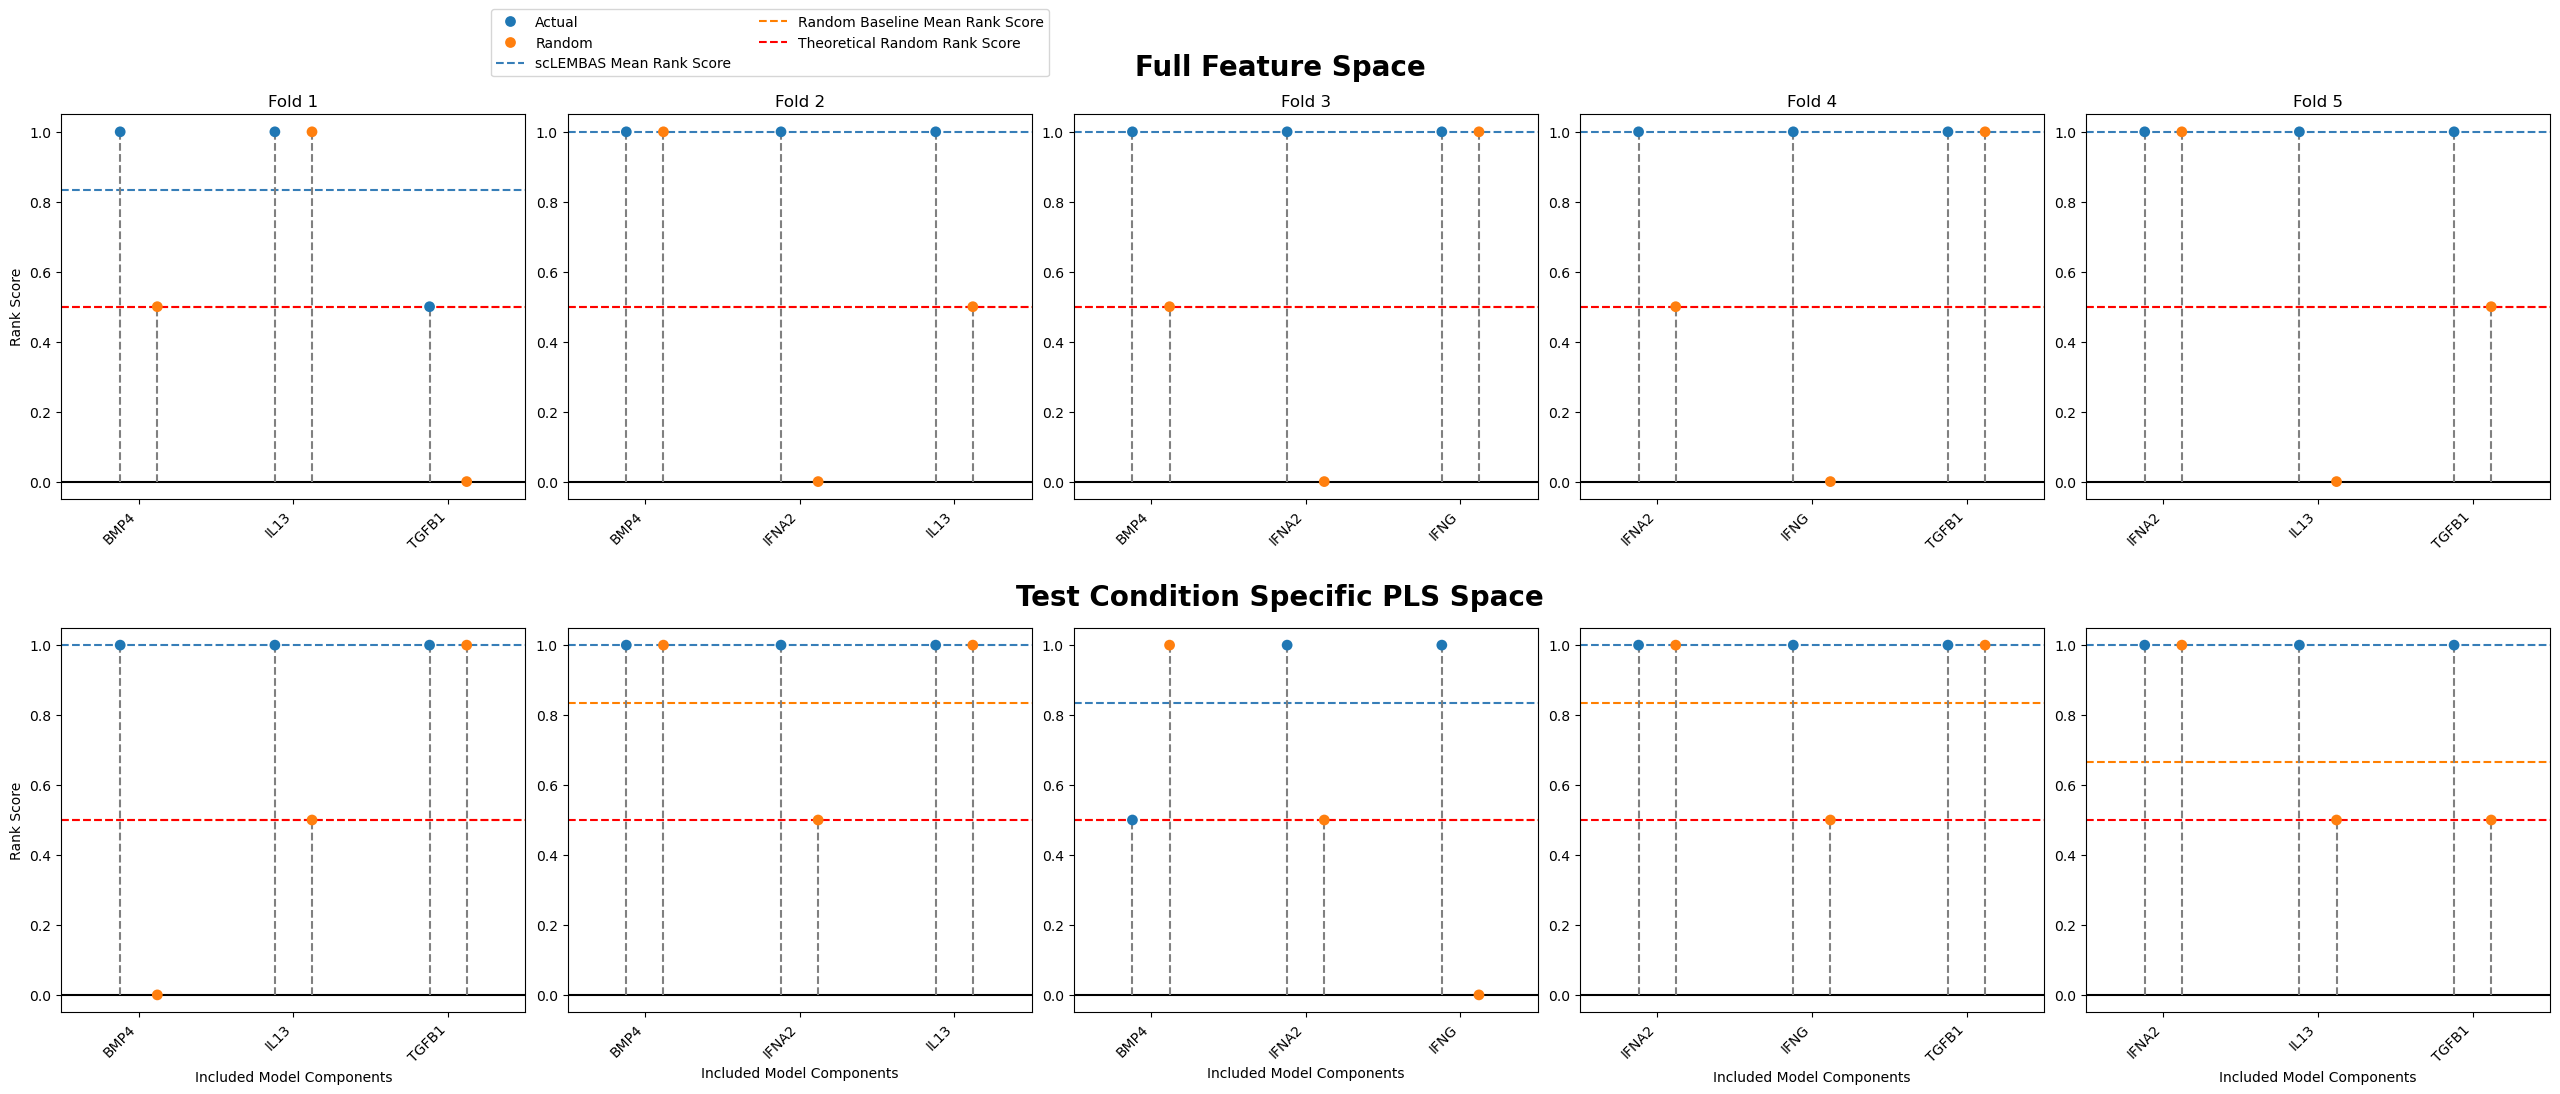

In [33]:
ncols = n_folds
nrows = 2
fig, ax = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5.1*ncols, 5.1*nrows),
    constrained_layout=True
)
fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

row_spaces = [
    "Full Feature Space",
    "Test Condition Specific PLS Space"
]

for i, space in enumerate(row_spaces):

    # ---- IMPORTANT: filter per row ----
    viz_df = loss_res[loss_res.Space == space].copy()

    for j in range(ncols):
        fold = j + 1
        viz_df_fold = viz_df[viz_df.Fold == fold].copy()
        # --- reshape to one row per (Perturbation, mod_type) ---
        viz_df_fold = (
            viz_df_fold
            .drop(columns=["Mean Rank Score"])
            .assign(**{
                "All Rank Scores": viz_df_fold["All Rank Scores"].apply(dict.items)
            })
            .explode("All Rank Scores")
            .assign(
                Perturbation=lambda x: x["All Rank Scores"].apply(lambda kv: kv[0]),
                Rank_Score=lambda x: x["All Rank Scores"].apply(lambda kv: kv[1]),
            )
            .drop(columns=["All Rank Scores"])
        )

        # Ensure order: Actual then Random
        viz_df_fold["mod_type"] = pd.Categorical(
            viz_df_fold["mod_type"],
            categories=["Actual", "Random"],
            ordered=True
        )

        # Order perturbations consistently (keep appearance stable)
        pert_order = list(pd.unique(viz_df_fold["Perturbation"]))
        viz_df_fold["Perturbation"] = pd.Categorical(
            viz_df_fold["Perturbation"],
            categories=pert_order,
            ordered=True
        )

        # --- build numeric x positions with small offsets for mod_type ---
        x_base = {p: k for k, p in enumerate(pert_order)}  # 0..K-1
        offset = {"Actual": -0.12, "Random": +0.12}        # close together

        viz_df_fold["xpos"] = viz_df_fold.apply(
            lambda r: x_base[r["Perturbation"]] + offset[r["mod_type"]],
            axis=1
        )

        # --- lollipop stems (behind points) ---
        for x, y in zip(viz_df_fold["xpos"], viz_df_fold["Rank_Score"]):
            ax[i, j].vlines(
                x, ymin=0, ymax=y,
                linestyle="dashed",
                color="gray",
                zorder=1
            )

        # --- points (colored by mod_type) ---
        sns.scatterplot(
            data=viz_df_fold,
            x="xpos",
            y="Rank_Score",
            hue="mod_type",
            hue_order=["Actual", "Random"],
            ax=ax[i, j],
            s=60,                # adjust marker size as you like
            edgecolor="none",
            zorder=2
        )

        # --- reference lines ---
        ax[i, j].axhline(y=0, color="black", zorder = 0)
        
        mean_actual = viz_df_fold[viz_df_fold.mod_type == 'Actual'].Rank_Score.mean()
        mean_rand = viz_df_fold[viz_df_fold.mod_type == 'Random'].Rank_Score.mean()
        
        ax[i, j].axhline(
            y=mean_actual,
            color=sns.color_palette('Set1')[1],
            linestyle="--",
            label="scLEMBAS Mean Rank Score", zorder = 0
        )
        
        ax[i, j].axhline(
            y=mean_rand,
            color=sns.color_palette('Set1')[4],
            linestyle="--",
            label="Random Baseline Mean Rank Score", zorder = 0
        )
        
        ax[i, j].axhline(
            y=0.5,
            color="red",
            linestyle="--",
            label="Theoretical Random Rank Score", zorder = 0
        )


        # --- x ticks: ONLY perturbations (centered between the two dots) ---
        ax[i, j].set_xticks(list(x_base.values()))
        ax[i, j].set_xticklabels(pert_order, rotation=45, ha="right")

        # make room for side-by-side points + keep groups separated
        ax[i, j].set_xlim(-0.5, len(pert_order) - 0.5)

        # axis labels
        ax[i, j].set_xlabel("Perturbation")
        ax[i, j].set_ylabel("Rank Score")

        # legend: keep mod_type colors, and optionally keep the 0.5 line label too
        handles, labels = ax[i, j].get_legend_handles_labels()
        # seaborn creates a legend with a "mod_type" title + entries; we keep it
        ax[i, j].legend(title="mod_type", frameon=False)

        ax[i, j].set_title(f"Fold {fold}")
        ax[i, j].set_xlabel("Included Model Components")

        if (i, j) == (0, 0):
            ax[i, j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        else:
            leg = ax[i, j].get_legend()
            if leg is not None:
                leg.remove()
        if j != 0:
            ax[i,j].set_ylabel('')
        if i != 1:
            ax[i,j].set_xlabel('')
        if i != 0:
            ax[i,j].set_title('')

# ---- shared legend (unchanged) ----
leg = ax[0, 0].get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.3, 1.075)
)
ax[0, 0].legend_.remove()

# ---- row-level "suptitles" ----
fig.text(0.5, 1.025, row_spaces[0], ha="center", va="top", fontsize=20, fontweight="bold")
fig.text(0.5, 0.505,  row_spaces[1], ha="center", va="top", fontsize=20, fontweight="bold")
;